### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_LSTM_P491 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, lstm, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

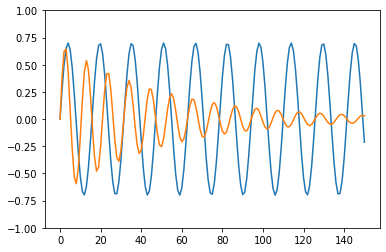

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 10

In [11]:
init_fun, qgru_rnn = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

491

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect 3 local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.00035520906790123216   1.87284517288208 sec        
199: 0.00021198603672758443   2.7778847217559814 sec      
299: 0.00037582698796466657   3.9281232357025146 sec      
399: 0.0001878728340343555   4.938074827194214 sec        
499: 0.00015150455480991755   5.9496448040008545 sec      
599: 0.00012861806069181179   6.8428850173950195 sec      
699: 0.00025086890571478676   7.755558967590332 sec       
799: 0.0001756686400743063   8.603327751159668 sec        
899: 0.00015281612508059848   9.448911428451538 sec      
learning rate: 0.1
999: 0.001368109186573443   10.36879014968872 sec        
1099: 0.0004973909438491989   11.294207096099854 sec      
1199: 0.00030164116485946636   12.189693450927734 sec      
learning rate: 0.05
1299: 0.0005887646875157954   13.054260730743408 sec       
1399: 0.00037175588723091095   13.909188747406006 sec      
1499: 0.00029203571009447417   14.794042587280273 sec      
1599: 0.0002364888791979697   15.65317702293396 sec     

26299: 8.175579134203863e-05   225.47296690940857 sec       
26399: 3.727407283231639e-05   226.28792452812195 sec       
learning rate: 0.05
26499: 0.00041852533081678255   227.1104018688202 sec       
26599: 0.0002023646211475768   227.93285584449768 sec       
26699: 0.00015259221668298775   228.8109290599823 sec       
learning rate: 0.025
26799: 0.0004494118858473697   229.6466200351715 sec        
26899: 0.00026074295714988995   230.4650058746338 sec       
26999: 0.00023158020942296015   231.2838490009308 sec       
learning rate: 0.0125
27099: 3.543078208850364e-05   232.12379550933838 sec       
27199: 3.449735779076353e-05   232.95338082313538 sec       
27299: 3.405884924751763e-05   233.78407526016235 sec       
27399: 3.3818060524143606e-05   234.6132390499115 sec       
27499: 3.36612994693707e-05   235.45439195632935 sec        
27599: 3.355054808607252e-05   236.32181453704834 sec       
learning rate: 0.2
27699: 0.00032514409003187776   237.16522669792175 sec      
277

52399: 3.3593235166963426e-05   444.79052233695984 sec      
52499: 3.3495755361043087e-05   445.6438901424408 sec       
52599: 3.3739372759287796e-05   446.46643686294556 sec      
52699: 3.352253069925231e-05   447.30898332595825 sec       
52799: 3.732966122150874e-05   448.16761302948 sec          
learning rate: 0.0125
52899: 3.393938995604106e-05   449.0092053413391 sec        
52999: 3.3649266285112025e-05   449.9322154521942 sec       
learning rate: 0.00625
53099: 3.353626797610917e-05   450.82176399230957 sec       
53199: 3.348605885230339e-05   451.6769802570343 sec        
learning rate: 0.2
53299: 0.0004023775284249251   452.54587507247925 sec       
53399: 0.0001909113760929619   453.38139152526855 sec       
53499: 0.00015829825880326337   454.2167603969574 sec       
53599: 0.00021556132898597889   455.04160046577454 sec      
53699: 0.00015510296655465877   455.8897681236267 sec       
53799: 0.00015007527331106955   456.74601101875305 sec      
53899: 0.000127459664

78599: 3.348520523249116e-05   664.8998918533325 sec       
78699: 3.4570069674952225e-05   665.7663145065308 sec      
78799: 3.659324974336941e-05   666.6321246623993 sec       
learning rate: 0.0125
78899: 3.41178191191969e-05   667.4765257835388 sec        
learning rate: 0.00625
78999: 3.331218382445581e-05   668.3041868209839 sec       
79099: 3.3263131355380366e-05   669.1352264881134 sec      
79199: 3.323038785162732e-05   670.0027995109558 sec       
79299: 3.3202579552171924e-05   670.8582882881165 sec      
learning rate: 0.2
79399: 0.001154554085034434   671.6876044273376 sec       
79499: 0.00030738955272502074   672.5081222057343 sec      
79599: 0.0002136903636283053   673.3235266208649 sec       
79699: 0.0001753204025982359   674.1292088031769 sec       
79799: 0.00012178081496862668   674.9407095909119 sec      
79899: 0.0008883627671863375   675.7821924686432 sec       
79999: 8.820609494584367e-05   676.5931441783905 sec       
80099: 7.122296295836033e-05   677.43

104699: 0.00012022667124506795   886.0293123722076 sec      
104799: 0.00010344551219913323   886.96000623703 sec        
104899: 0.00018560838079895587   887.8667821884155 sec      
104999: 0.00012304041707592646   888.775749206543 sec       
105099: 0.00010304264103321392   889.6868658065796 sec      
105199: 8.578441735051758e-05   890.6106557846069 sec       
105299: 7.577953425692821e-05   891.5210702419281 sec       
105399: 5.7607003806050465e-05   892.4209523200989 sec      
105499: 6.733917511788853e-05   893.3226969242096 sec       
105599: 5.0102232460999766e-05   894.2305970191956 sec      
105699: 4.2685377385639654e-05   895.1900541782379 sec      
105799: 3.785846710231283e-05   896.1476404666901 sec       
105899: 3.590128844204806e-05   897.0474214553833 sec       
105999: 3.478411589787214e-05   897.9807119369507 sec       
106099: 3.4099798783829845e-05   898.8727583885193 sec      
106199: 3.370117156449721e-05   899.8026571273804 sec       
106299: 3.34585534131762

...

156099: 0.00010331665183792574   1326.8785769939423 sec      
156199: 8.493964592688696e-05   1327.6264188289642 sec       
156299: 7.341317521510001e-05   1328.388682603836 sec       
156399: 0.00970799486201413   1329.140260219574 sec          
156499: 0.00013294139152785275   1329.9048182964325 sec      
156599: 0.00010659785346086876   1330.6518242359161 sec      
learning rate: 0.1
156699: 0.0010733341012594817   1331.3882539272308 sec      
156799: 0.0004318058597202812   1332.1170597076416 sec       
156899: 0.0003503685366887241   1332.8877289295197 sec       
learning rate: 0.05
156999: 0.00018765924022770227   1333.6429071426392 sec      
157099: 9.860033289448327e-05   1334.3740866184235 sec       
157199: 7.889674517779946e-05   1335.115751028061 sec       
157299: 7.261891297108492e-05   1335.8617374897003 sec      
157399: 6.841085052234536e-05   1336.6002333164215 sec      
157499: 6.453034011770895e-05   1337.340458393097 sec       
157599: 6.0740414975773414e-05   1338

181699: 0.0003164870970776876   1519.4404435157776 sec       
181799: 0.00019279235260872386   1520.1910202503204 sec      
181899: 0.00015620400705617252   1520.9404430389404 sec      
181999: 0.00019644727379897046   1521.6955695152283 sec      
182099: 0.00013718065086803618   1522.4329006671906 sec      
182199: 8.499908145064278e-05   1523.1635665893555 sec       
182299: 5.946146467473035e-05   1523.9025230407715 sec       
182399: 0.00010236480194280024   1524.6500985622406 sec      
182499: 6.562972760947468e-05   1525.3818671703339 sec       
182599: 5.2451446994222963e-05   1526.1273782253265 sec      
182699: 0.00020345645884700022   1526.8672473430634 sec      
182799: 8.490895567538282e-05   1527.6106870174408 sec       
182899: 4.914152103342128e-05   1528.3620643615723 sec       
182999: 6.239467994331882e-05   1529.1047520637512 sec       
183099: 0.00026185769575782673   1529.836480140686 sec       
183199: 0.00014224271911299707   1530.5721423625946 sec      
learning

207299: 0.00014982704135450535   1711.8682706356049 sec      
207399: 0.00012125610433916957   1712.6078951358795 sec      
207499: 0.004435670283800499   1713.356502532959 sec         
207599: 0.00019068188161145406   1714.0952606201172 sec      
207699: 0.0001709581201918523   1714.8387477397919 sec       
learning rate: 0.1
207799: 0.0005374188378726895   1715.5927922725677 sec      
207899: 0.00031090564973015823   1716.3320479393005 sec      
207999: 0.00020632392388027346   1717.0689644813538 sec      
learning rate: 0.05
208099: 0.0004976141569043913   1717.8076255321503 sec      
208199: 0.00022592550603034092   1718.545491218567 sec       
208299: 0.00018223814739134122   1719.277168750763 sec       
208399: 0.00016455894724742682   1720.0110201835632 sec      
208499: 0.0001540945512878343   1720.7758629322052 sec       
208599: 0.00014650121712312888   1721.5453970432281 sec      
208699: 0.0001386202369826866   1722.2913281917572 sec       
208799: 0.0001290628819474416   1

232899: 6.23937533495877e-05   1904.468118429184 sec        
232999: 5.8467797325010304e-05   1905.463474035263 sec       
233099: 5.349335695918894e-05   1906.2699995040894 sec       
233199: 4.961379850956214e-05   1907.0190105438232 sec       
233299: 4.680093430621188e-05   1907.7664918899536 sec       
233399: 8.222744738592781e-05   1908.5031960010529 sec       
233499: 5.156356303530482e-05   1909.2625744342804 sec       
233599: 4.594517027060673e-05   1910.0078439712524 sec       
233699: 4.343812000595476e-05   1910.7546954154968 sec       
233799: 4.32992467844596e-05   1911.5010380744934 sec        
233899: 4.0588133603048904e-05   1912.2509984970093 sec      
233999: 3.9105198059270216e-05   1912.9798305034637 sec      
234099: 3.780938854758732e-05   1913.7078993320465 sec       
234199: 3.762780612598895e-05   1914.4646887779236 sec       
234299: 3.644959809405933e-05   1915.2044594287872 sec       
234399: 3.623211301523695e-05   1915.9546027183533 sec       
234499: 3

258499: 5.5795601753298155e-05   2096.6981053352356 sec      
258599: 3.447648821788377e-05   2097.454998731613 sec        
258699: 3.4535737671054e-05   2098.2174010276794 sec         
258799: 3.760225118425977e-05   2098.976134300232 sec        
258899: 3.522580990113137e-05   2099.705863237381 sec        
learning rate: 0.025
258999: 6.826683317443911e-05   2100.440600633621 sec        
learning rate: 0.0125
259099: 3.613780489442043e-05   2101.1992559432983 sec       
259199: 3.442931682760702e-05   2101.945883989334 sec        
259299: 3.385506402282194e-05   2102.6851994991302 sec       
259399: 3.356958360623451e-05   2103.430358171463 sec        
259499: 3.343066138744666e-05   2104.1801908016205 sec       
259599: 3.335380492120564e-05   2104.909614801407 sec        
learning rate: 0.2
259699: 0.00026310266278853394   2105.6540915966034 sec      
259799: 0.00017469952514164268   2106.3959889411926 sec      
259899: 0.00012071546423771787   2107.121738433838 sec       
259999: 

In [23]:
minLoss

Array(3.30021611e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

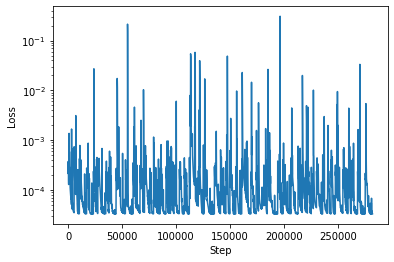

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

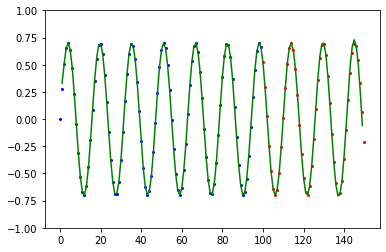

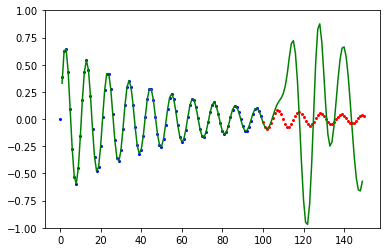

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

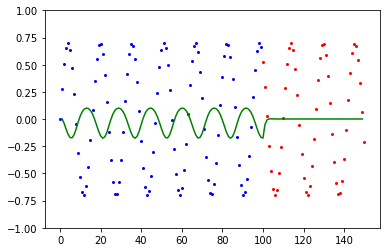

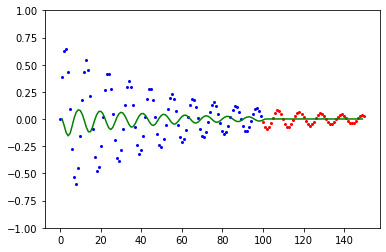

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[213300,
 Array(3.31040796e-05, dtype=float64),
 Array(0.00017935, dtype=float64),
 [(Array([[ 0.49341992, -0.84477345, -0.29973321, -0.30666873, -0.08218095,
            0.18843543, -0.36101604,  0.4124712 , -0.40778446, -0.07252678]],      dtype=float64),
   Array([[ 0.16235438,  0.20314309,  0.3284991 , -0.49108388, -0.26337268,
            0.20460508, -0.3170704 , -0.48050073,  0.04128591,  0.0161786 ],
          [ 0.65825593,  0.25157008,  0.02311331, -0.49978202, -0.36376244,
            0.28138841, -0.1763747 ,  0.32237967, -0.23763336, -0.60315946],
          [-0.44455194,  0.06566419,  0.0239671 ,  0.14904986, -0.37302687,
            0.25394499, -0.03271066,  0.02430482,  0.45912709, -0.39337351],
          [-0.10544881, -0.42648836, -0.34010278,  0.40051461,  0.17070174,
            0.26383405, -0.0921004 ,  0.03668378, -0.48765987, -0.00458148],
          [ 0.40399603,  0.29689255, -0.09725199, -0.39162924, -0.55090264,
            0.27824391,  0.23889863,  0.10285161,  0.0

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

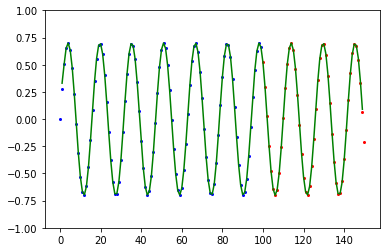

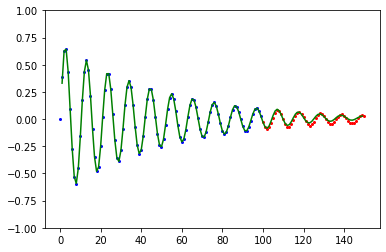

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [213300, Array(3.31040796e-05, dtype=float64), Array(0.00017935, dtype=float64)]
5600 3.4904285138936344e-05 0.012838230602729496


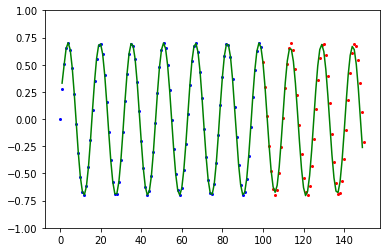

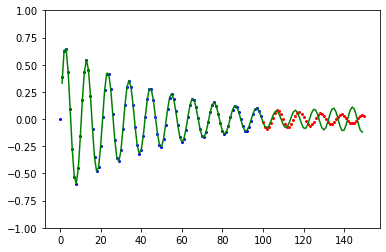

10500 3.325034207401272e-05 0.8010872012854132


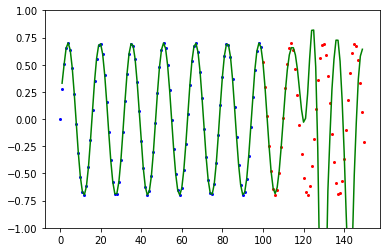

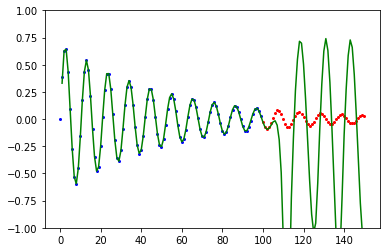

17200 3.3265964919508845e-05 3.145021085442715


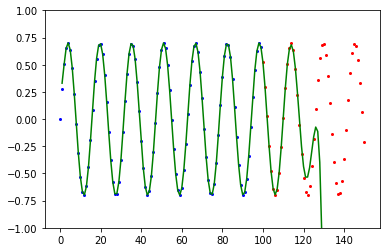

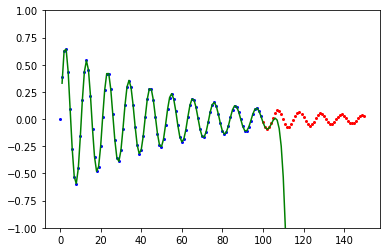

23500 3.300424154254223e-05 0.11152462897224999


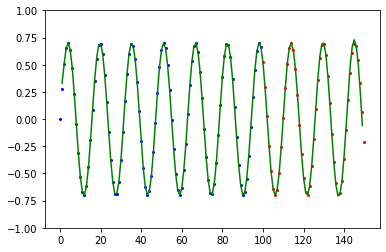

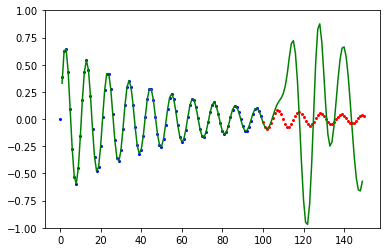

27600 3.355054808607252e-05 0.062278953525176955


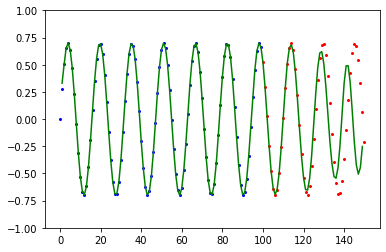

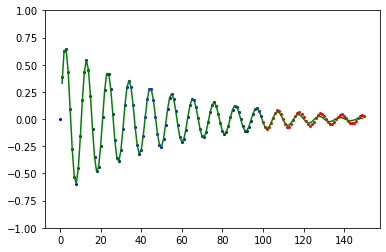

35000 3.333563638929137e-05 0.05407324185179675


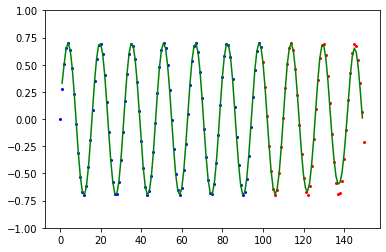

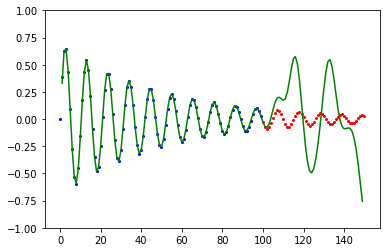

38000 3.4536253394875574e-05 0.32223366325889247


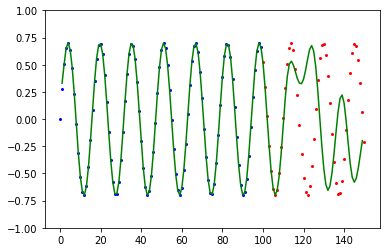

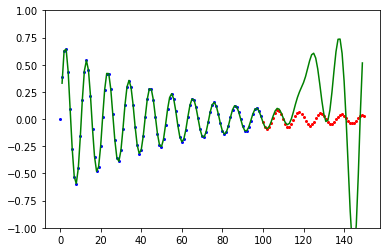

44500 3.3044789629172105e-05 3.167070346307828


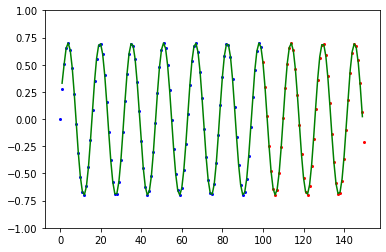

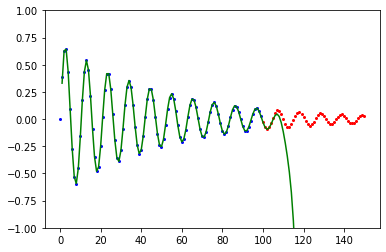

53200 3.348605885230339e-05 1.1989222003422952


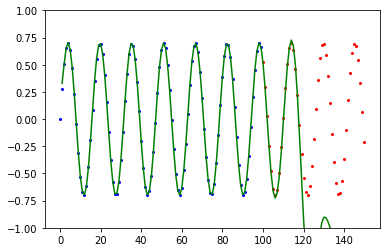

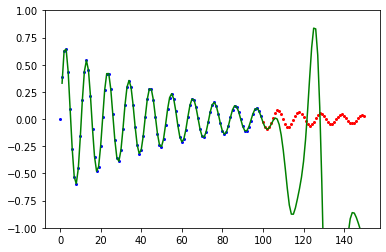

60300 3.3156128279393915e-05 0.07876391078284563


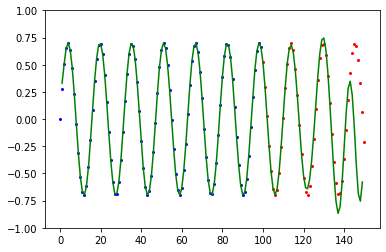

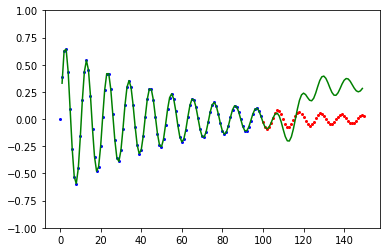

66700 3.3800731742151316e-05 0.6936234102715482


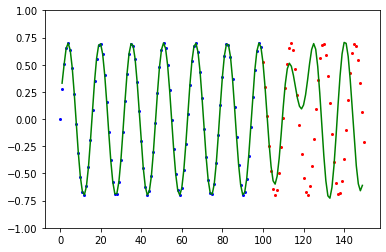

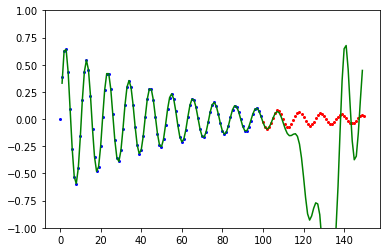

70900 3.538601772019082e-05 0.4087060357452197


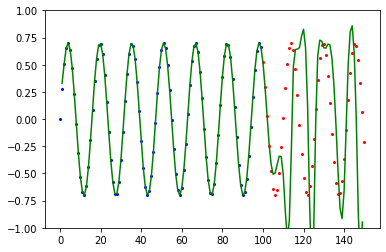

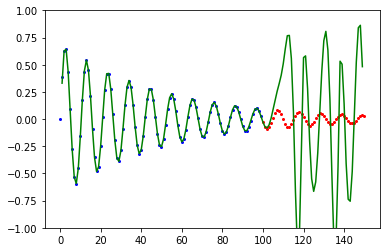

75900 3.3701700483819456e-05 0.7712557839287293


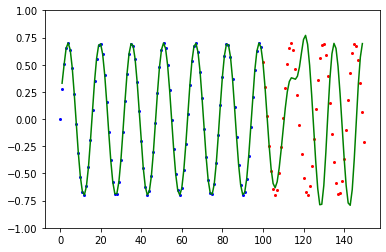

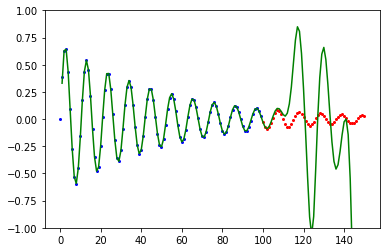

79300 3.3202579552171924e-05 0.3434397663988722


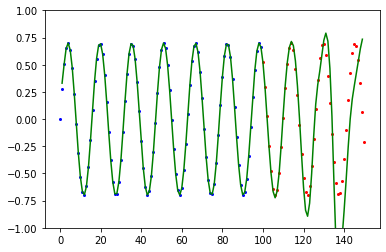

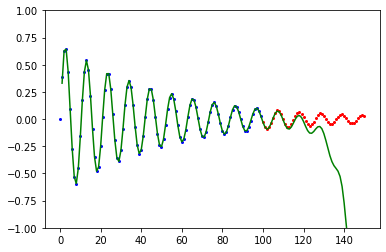

85400 3.3295653083658055e-05 0.007247833572134925


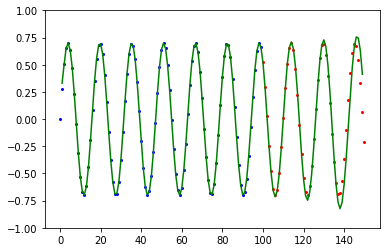

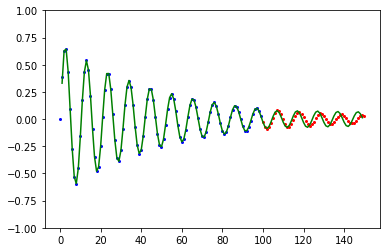

90800 3.313393131330335e-05 0.06859886477733573


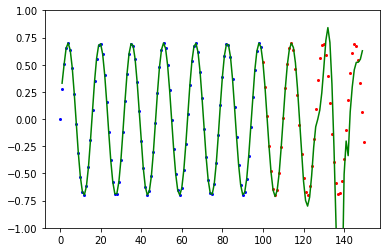

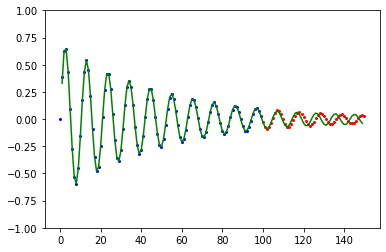

95000 3.373721806469914e-05 0.025512696742048546


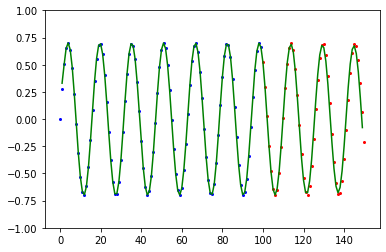

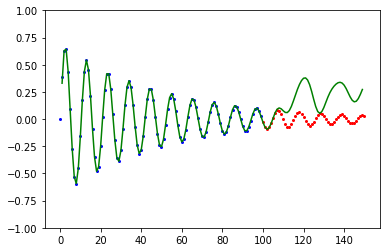

98300 3.3554860161949884e-05 0.02193460652712501


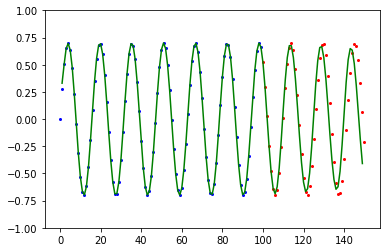

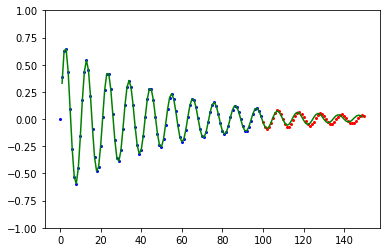

103200 3.345197845700075e-05 0.0008590654997258512


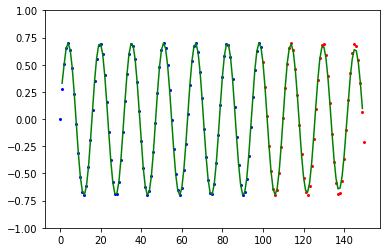

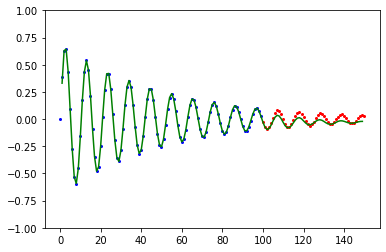

107800 3.31960971843013e-05 0.5095862897779152


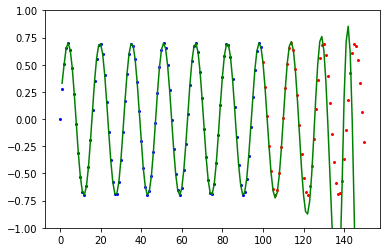

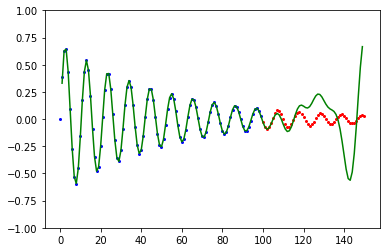

112500 3.3197521267423744e-05 0.015354632575929728


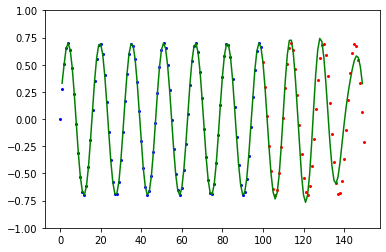

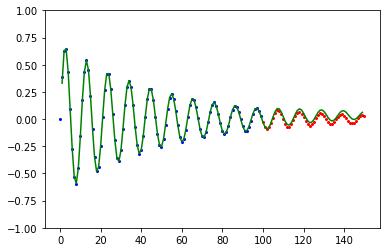

120800 4.7241370757551996e-05 0.3285318211939416


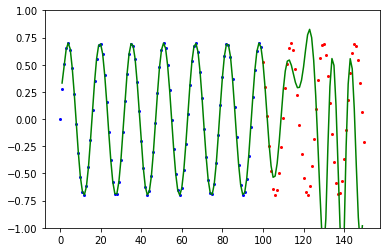

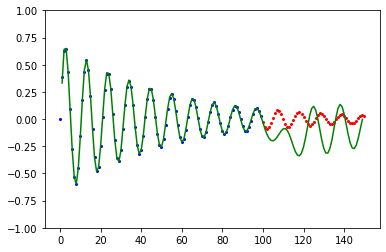

126000 3.319734228266618e-05 0.00018065958667415506


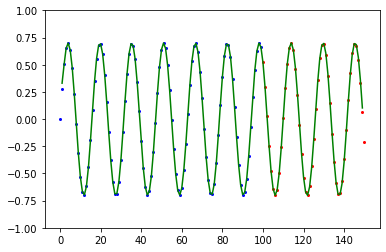

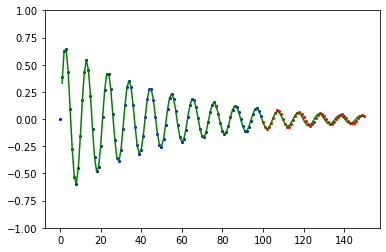

135700 3.301909953251505e-05 0.010367153018910367


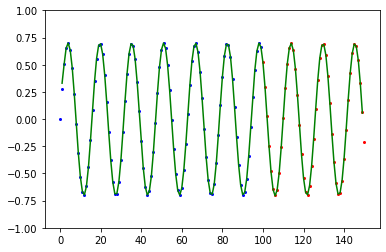

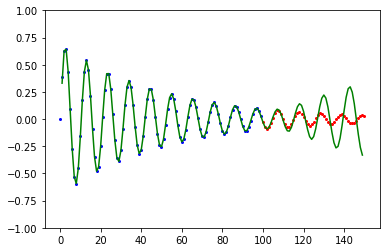

141400 3.3508386868358385e-05 1.8851440608738907


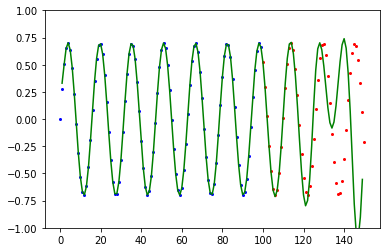

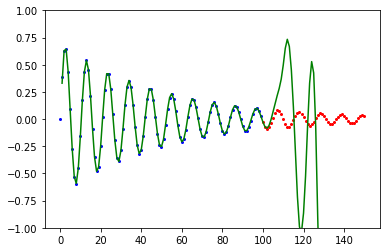

146400 3.328201337048628e-05 0.02341706060171298


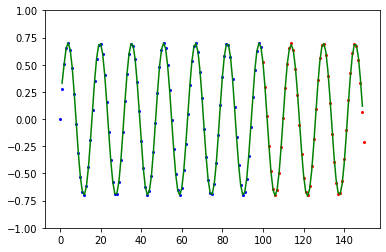

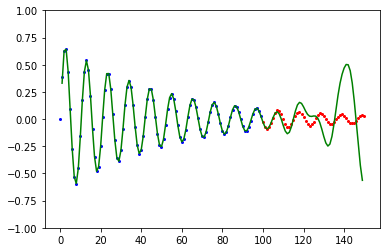

150100 3.3212875998126075e-05 0.1653421585451462


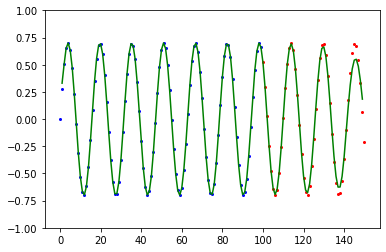

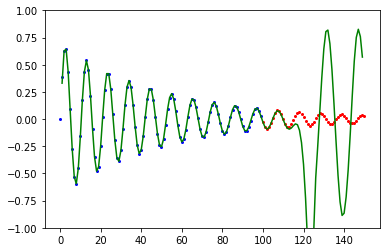

155500 3.304526820166666e-05 0.08565928662587358


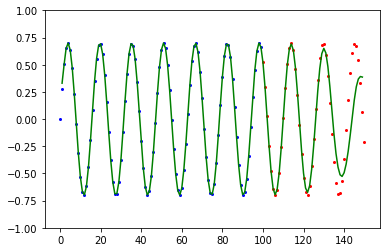

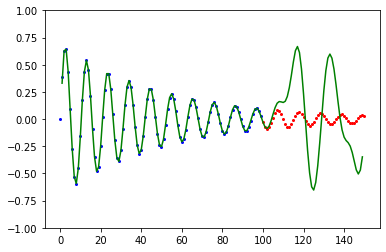

161100 3.320846509486005e-05 0.040712815768872125


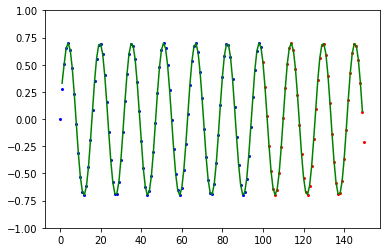

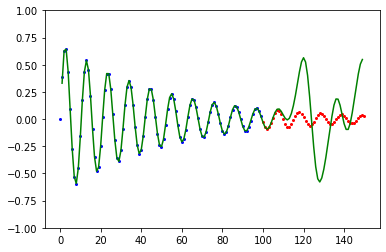

169600 3.3263807765699825e-05 0.1781732612538349


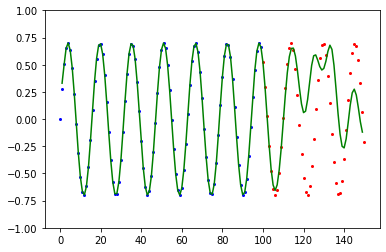

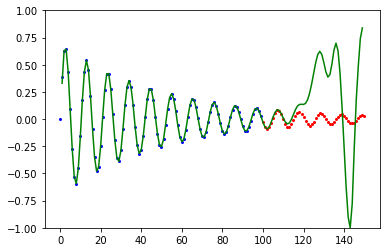

174400 3.335250641195661e-05 0.810580063485367


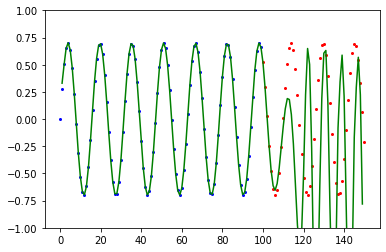

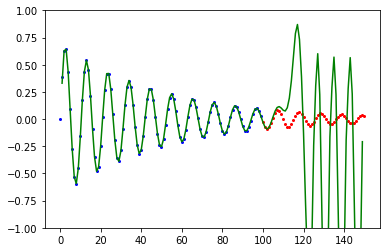

181600 4.831639145498346e-05 0.09133750608344783


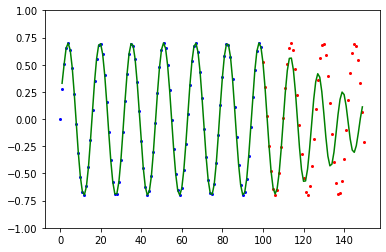

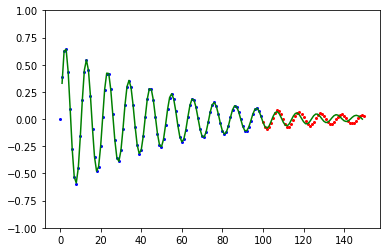

184700 3.327520277467301e-05 0.024108317619755463


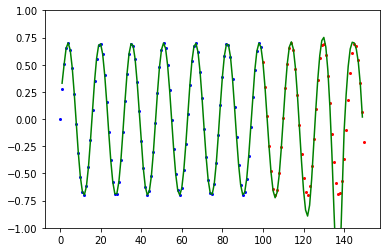

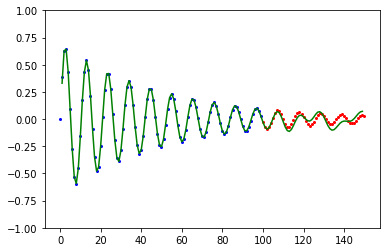

194400 3.306506846431876e-05 0.0024028467908109785


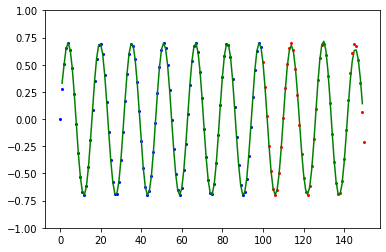

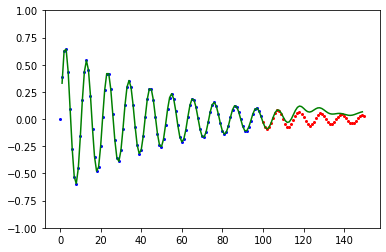

199400 3.330251993503665e-05 0.0024054285660602367


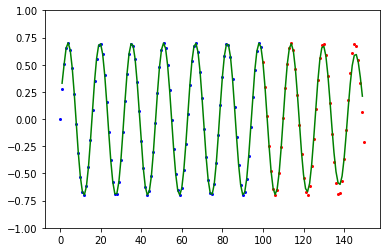

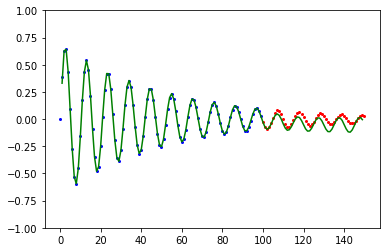

206800 3.3392429887813174e-05 0.09553898323019365


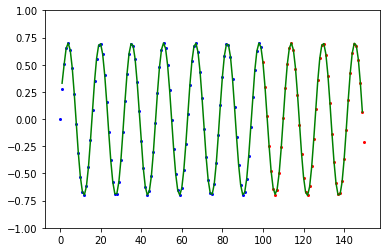

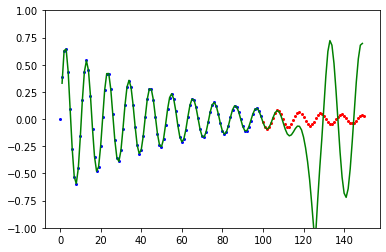

213300 3.310407963309916e-05 0.00017935097208601473


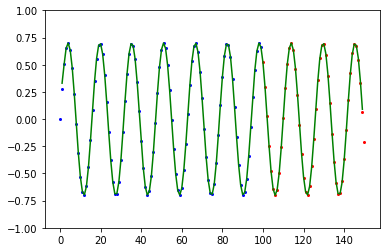

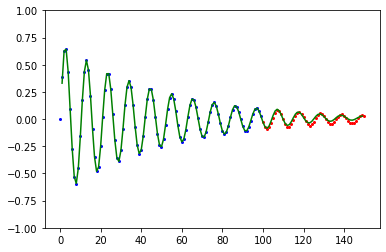

222000 3.4271394773510896e-05 0.08340723043869906


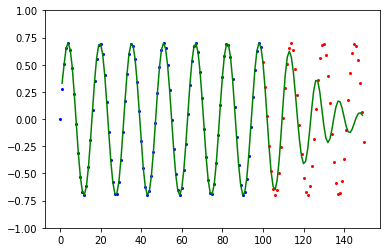

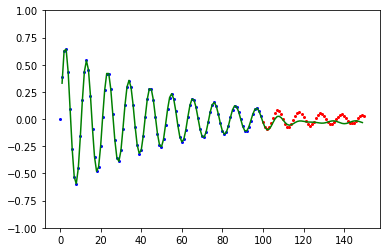

225600 3.333363204290014e-05 0.056673251071130006


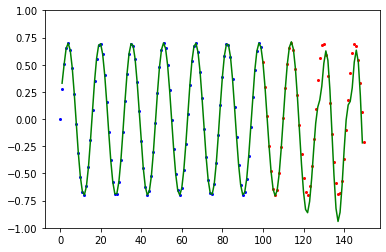

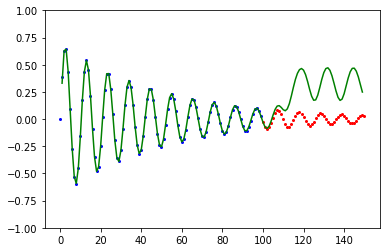

230400 4.396341484636703e-05 0.049031138181745176


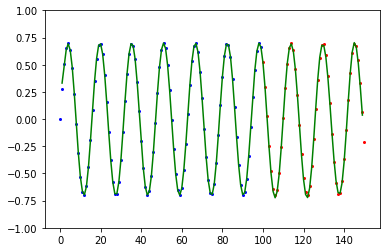

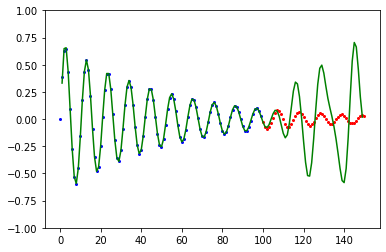

236100 3.309772467930946e-05 0.9787962733785586


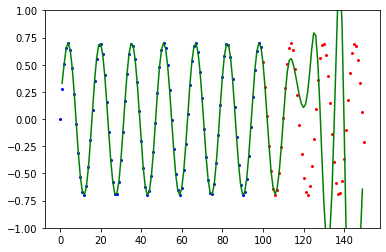

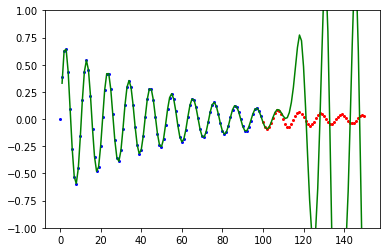

240700 3.4058300251543854e-05 0.41380012332969335


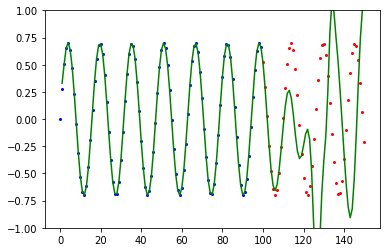

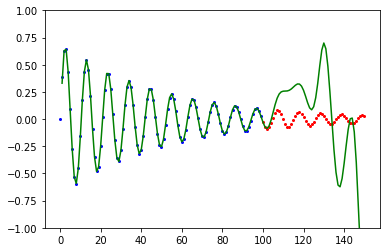

243900 3.314260040544088e-05 0.014896422665081389


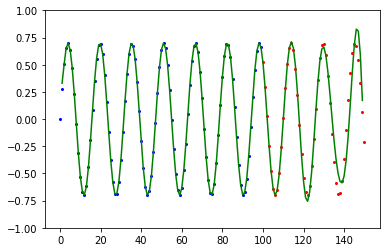

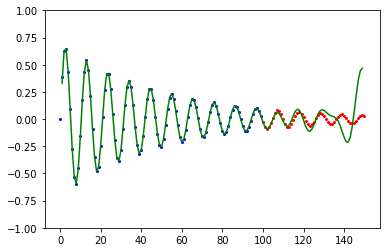

247900 3.325561938591163e-05 0.000764687495386465


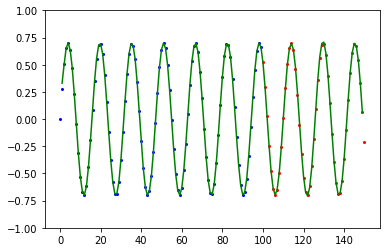

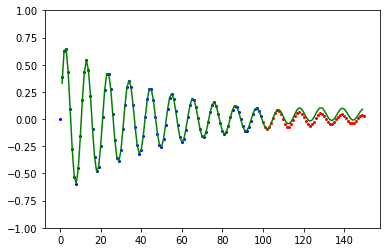

254900 3.397195632185529e-05 0.014179138412553931


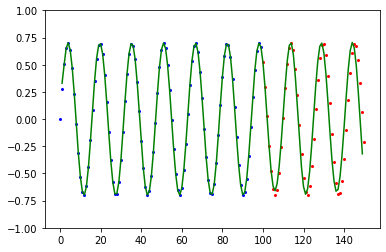

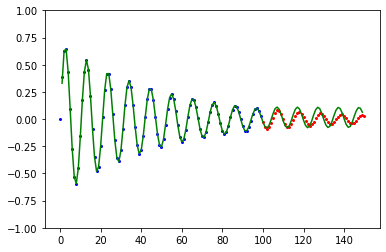

259600 3.335380492120564e-05 0.05927625049091979


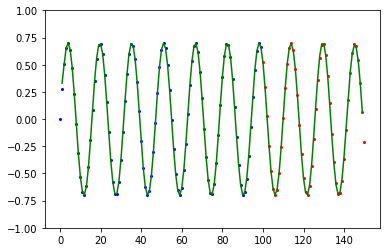

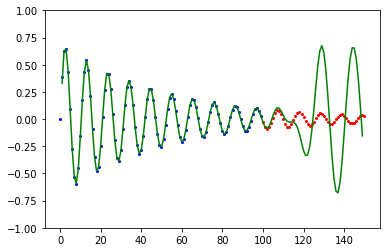

262700 3.353985311741636e-05 0.043683341719545375


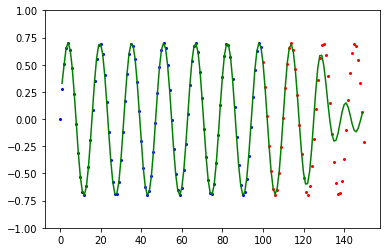

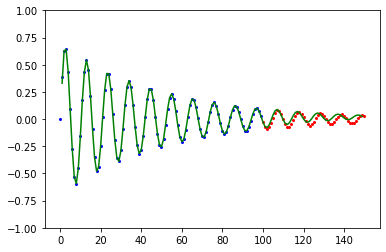

268500 3.3117133833876905e-05 0.03320351668147268


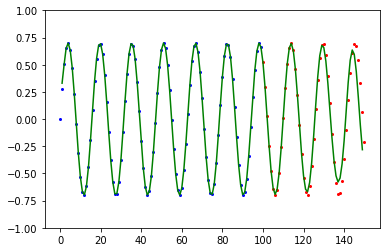

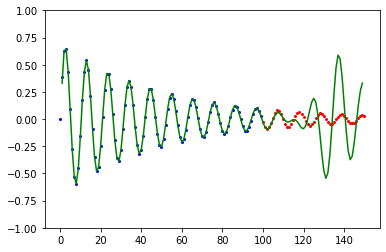

275600 3.309016499819301e-05 0.2702895238333903


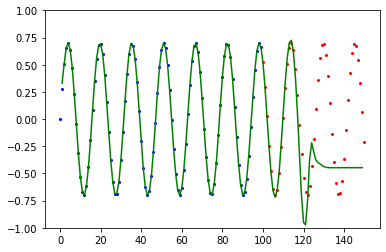

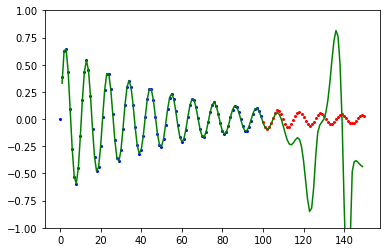

282400 3.3073297663264e-05 5.853313110877912


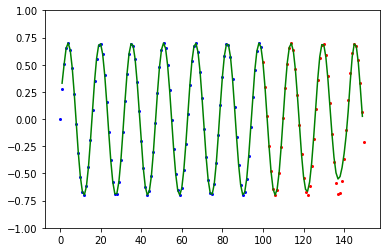

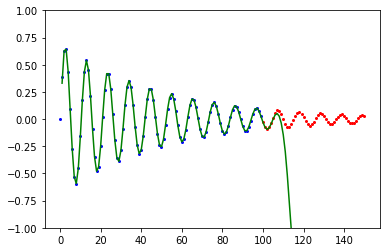

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.46870654, dtype=float64)

In [35]:
len(test_result)

50